## Kapitel 4 uppgift 14

 Nedan ser vi en början till modellering av ett mycket berömt dataset kopp
lat till blommor. Läs på vad datasetet innebär och genomför ett komplett
ML-flöde. Börja med att göra ett grundläggande flöde som fungerar, där
efter kan du om du önskar försöka förbättra resultatet.

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


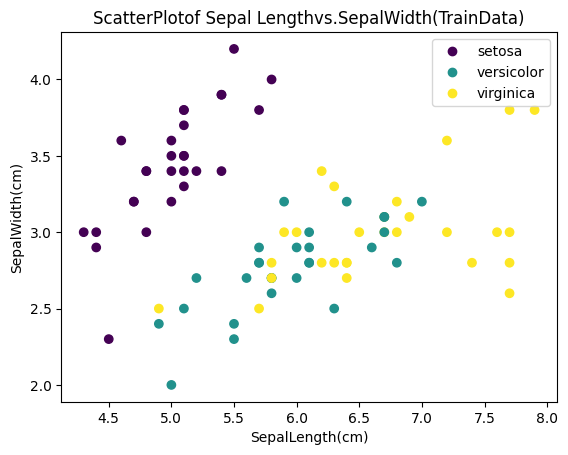

In [12]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import numpy as np


# Ladda Iris-data som DataFrame
X, y = load_iris(return_X_y=True, as_frame=True)

# Kolla kolumnnamn
print(X.columns.tolist())
# ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# Välj endast två kolumner
X = X[['sepal length (cm)', 'sepal width (cm)']]


# 80% train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40, stratify=y
)

# 30% av train som val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.3, random_state=36, stratify=y_train_full
)

classes = ['setosa', 'versicolor', 'virginica']
scatter = plt.scatter(X_train['sepal length (cm)'],
X_train['sepal width (cm)'], c=y_train)
plt.xlabel('SepalLength(cm)')
plt.ylabel('SepalWidth(cm)')
plt.title('ScatterPlotof Sepal Lengthvs.SepalWidth(TrainData)')
plt.legend(handles=scatter.legend_elements()[0],
labels=classes)


In [ ]:
# Standardisera data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Träna logistisk regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
# Predict på val och test
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

print("=== Validation Set ===")
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

print("=== Test Set ===")
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

=== Validation Set ===
[[12  0  0]
 [ 0 10  2]
 [ 0  4  8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.71      0.83      0.77        12
           2       0.80      0.67      0.73        12

    accuracy                           0.83        36
   macro avg       0.84      0.83      0.83        36
weighted avg       0.84      0.83      0.83        36

=== Test Set ===
[[10  0  0]
 [ 0  6  4]
 [ 0  3  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.67      0.60      0.63        10
           2       0.64      0.70      0.67        10

    accuracy                           0.77        30
   macro avg       0.77      0.77      0.77        30
weighted avg       0.77      0.77      0.77        30



In [22]:
# ROC-AUC för multiclass
from sklearn.preprocessing import label_binarize
y_val_bin = label_binarize(y_val, classes=[0,1,2])
y_val_proba = model.predict_proba(X_val_scaled)

# ROC-AUC för varje klass
for i in range(3):
    auc = roc_auc_score(y_val_bin[:,i], y_val_proba[:,i])
    print(f"Class {i} ROC-AUC: {auc:.3f}")

Class 0 ROC-AUC: 1.000
Class 1 ROC-AUC: 0.898
Class 2 ROC-AUC: 0.925


## visualisering

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

In [20]:
# Skapa meshgrid för plot
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Prediktera på alla punkter i grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Skapa färger
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold  = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

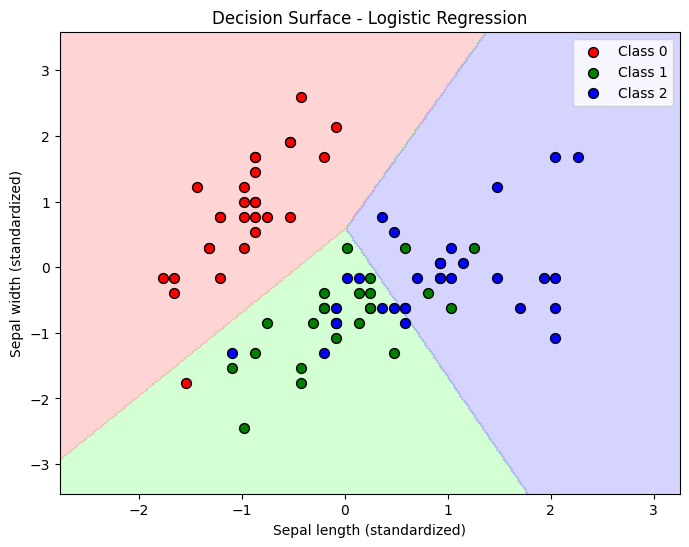

In [21]:
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)

# Plot träningsdata
for i, color in zip([0,1,2], ['red','green','blue']):
    plt.scatter(X_train_scaled[y_train==i, 0], X_train_scaled[y_train==i, 1],
                c=color, label=f"Class {i}", edgecolor='k', s=50)

plt.xlabel('Sepal length (standardized)')
plt.ylabel('Sepal width (standardized)')
plt.title('Decision Surface - Logistic Regression')
plt.legend()
plt.show()